In [69]:
import pandas as pd
import numpy as np
import sklearn as sk
import sklearn.preprocessing
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df = pd.read_csv('abalone.data', header=None)
df.head()

,0,1,2,3,4,5,6,7,8
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [71]:
df.columns = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
              'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
print(df.columns)

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='str')


In [72]:
df.info()

print('Amount of nulls - ', df.isnull().sum())

print("Stats - ", df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 297.9 KB
Amount of nulls -  Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64
Stats -              Length     Diameter       Height  Whole_weight  Shucked_weight  \
count  4177.000000  4177.000000  4177.000000   4177

In [73]:
df['Volume'] = df['Length'] * df['Diameter'] * df['Height']
df['Aspect_Ratio'] = df['Length'] / df['Diameter']

print(df.columns)
print(df.head())

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings', 'Volume', 'Aspect_Ratio'],
      dtype='str')
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings    Volume  Aspect_Ratio  
0         0.150     15  0.015777      1.246575  
1         0.070      7  0.008347      1.320755  
2         0.210      9  0.030051      1.261905  
3         0.155     10  0.020075      1.205479  
4         0.055      7  0.006732      1.294118  


In [74]:
x = df.drop(columns=['Rings', 'Sex'])
y = df['Rings']

x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(x, y, test_size=0.2, random_state=42)

sc = sklearn.preprocessing.StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

parameters = {'n_neighbors': [3, 5, 7, 9, 11, 15, 19], 'weights': ['uniform', 'distance']}
model = GridSearchCV(KNeighborsRegressor(), parameters, cv=5)
model.fit(x_train_scaled, y_train)

score = model.score(x_test_scaled, y_test)
print('Best params - ', model.best_params_)
print('Determination - ', score)

Best params -  {'n_neighbors': 19, 'weights': 'distance'}
Determination -  0.503306718091401


In [75]:
x_cls = df.drop(columns=['Sex'])
y_cls = df['Sex']

x_train_c, x_test_c, y_train_c, y_test_c = sk.model_selection.train_test_split(
    x_cls, y_cls, test_size=0.2, random_state=42
)

sc_c = sklearn.preprocessing.StandardScaler()

x_train_scaled_c = sc_c.fit_transform(x_train_c)
x_test_scaled_c = sc_c.transform(x_test_c)

parameters = {'n_neighbors': [3, 5, 7, 9, 11, 15, 19], 'weights': ['uniform', 'distance']}
model_cls = GridSearchCV(KNeighborsClassifier(), parameters, cv=5)
model_cls.fit(x_train_scaled_c, y_train_c)

score_c = model_cls.score(x_test_scaled_c, y_test_c)
print('Best params - ', model_cls.best_params_)
print('Determination - ', score_c)

Best params -  {'n_neighbors': 19, 'weights': 'distance'}
Determination -  0.5442583732057417


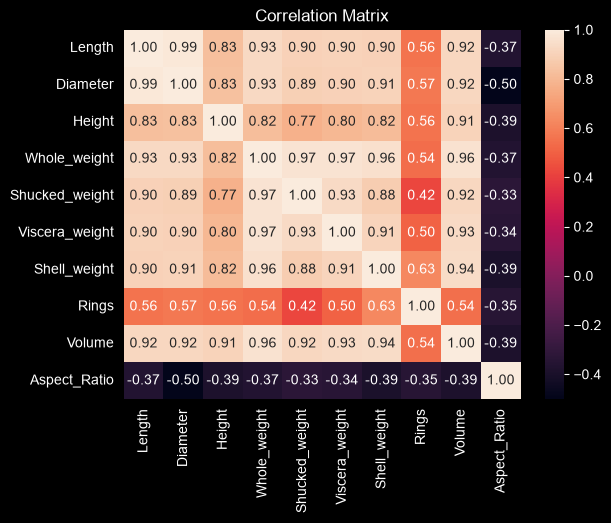

In [76]:
sns.heatmap(df.drop(columns=['Sex']).corr(), annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# This image shows which feature parameters influence Rings the most

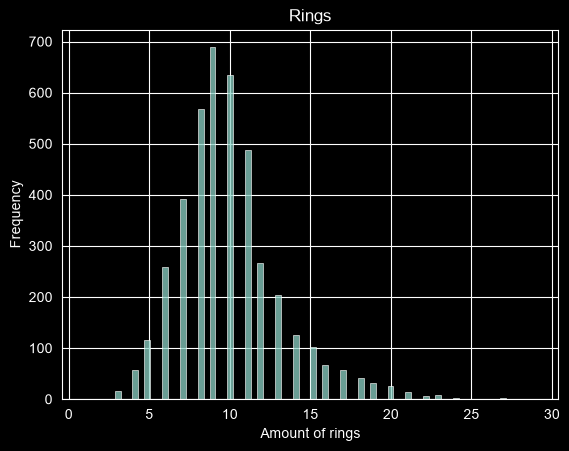

In [77]:
sns.histplot(data=df, x='Rings')
plt.title('Rings')
plt.xlabel('Amount of rings')
plt.ylabel('Frequency')
plt.show()

# This images shows how many rings has specific rows in dataset